In [1]:
import warnings

warnings.filterwarnings("ignore")

import sys
import os

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

#plt.style.use("ggplot")
sns.set_theme(style="ticks")
sns.set_context("paper")
sns.color_palette("husl", 8)
#plt.style.use('grayscale')


from tqdm import tqdm
from scipy import stats
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.linear_model import (
    LogisticRegressionCV,
    LassoCV,
    Lasso,
    ElasticNetCV,
    LogisticRegression,
)

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GroupKFold, KFold

sys.path.append(os.path.abspath("../"))
from dmldid.model_rcs import DMLDiD_RCS

# original data + fixed data processing process
- There is a bug in the data processing process in Chang(2020).
- Minimal processing process fixed.

## setup

In [2]:
DATA_PATH = "data/Bribes_Regression.dta"

df = pd.read_stata(DATA_PATH)
df = df.rename(columns={"lba": "Y", "tariff_change_2008": "D", "post_2008": "T"})
df.head().T


,0,1,2,3,4
ship_id,1.0,2.0,3.0,4.0,5.0
month_arrival,12.0,3.0,12.0,8.0,8.0
year,1.0,4.0,1.0,4.0,4.0
hc_group,15.0,12.0,3.0,14.0,14.0
hc_4digits,9405.0,8215.0,2202.0,8703.0,8703.0
reason_bribe,congestion,undervalue,undervalue,NaN,NaN
bp,NaN,0.0,1.0,1.0,0.0
actual_tariff_year,NaN,0.0,20.0,20.0,20.0
rsa,1,0,1,0,0
perishable,0.0,0.0,0.0,0.0,0.0


In [3]:
del df["day_w_arrival_post2008"]
del df["psi_post_2008"]
df = pd.concat(
    [
        df,
        pd.get_dummies(df["hc_4digits"], drop_first=True, prefix="hc_4digits"),
        pd.get_dummies(df["reason_bribe"], drop_first=True, prefix="reason_bribe"),
        pd.get_dummies(df["b_recipient"], drop_first=True, prefix="b_recipient"),
        pd.get_dummies(df["day_w_arrival"], drop_first=True, prefix="day_w_arrival"),
        pd.get_dummies(df["monitor"], drop_first=True, prefix="monitor"),
        pd.get_dummies(df["psi"], drop_first=True, prefix="psi"),
        pd.get_dummies(df["term"], drop_first=True, prefix="term"),
        pd.get_dummies(
            df["clear_agent"].fillna(99).astype(int),
            drop_first=True,
            prefix="clear_agent",
        ),
        pd.get_dummies(
            df["hc_group"].fillna(99).astype(int), drop_first=False, prefix="hc_group"
        ),
    ],
    axis=1,
).drop(
    [
        "hc_4digits",
        "reason_bribe",
        "b_recipient",
        "day_w_arrival",
        "monitor",
        "psi",
        "term",
        "clear_agent",
        "hc_group",
    ],
    axis=1,
)

df.head().T

,0,1,2,3,4
ship_id,1.0,2.0,3.0,4.0,5.0
month_arrival,12.0,3.0,12.0,8.0,8.0
year,1.0,4.0,1.0,4.0,4.0
bp,NaN,0.0,1.0,1.0,0.0
actual_tariff_year,NaN,0.0,20.0,20.0,20.0
...,...,...,...,...,...
hc_group_12,0.0,1.0,0.0,0.0,0.0
hc_group_13,0.0,0.0,0.0,0.0,0.0
hc_group_14,0.0,0.0,0.0,1.0,1.0
hc_group_15,1.0,0.0,0.0,0.0,0.0


In [4]:
X_cols = [
    "tariff2007",
    "lvalue_tonnage",
    "differentiated",
    "agri",
    "perishable",
    "dfs",
    "rsa",
]
monitor_cols = [col for col in df.columns if "monitor" in col]
dwa_cols = [col for col in df.columns if "day_w_arrival" in col]
psi_cols = [col for col in df.columns if "psi" in col]
clear_agent_cols = [col for col in df.columns if "clear_agent" in col]
hc_group_cols = [col for col in df.columns if "hc_group" in col]
id_cols = [col for col in df.columns if "hc_4digits" in col]

In [5]:
X_cols = X_cols + dwa_cols + monitor_cols + psi_cols + clear_agent_cols + hc_group_cols + id_cols
y_col = "Y"
d_col = "D"
t_col = "T"

In [6]:
df_dropna = df[X_cols + [y_col , d_col , t_col]].dropna().reset_index(drop=True)

In [7]:
print("missing ratio :", len(df_dropna) / len(df))

missing ratio : 0.44226044226044225


## Chang (2020)
- The following R code is from [Chang (2020)](https://github.com/NengChiehChang/Diff-in-Diff/blob/master/Table%202/DMLML.R).
- DMLML:Unchanged except for the addition of a progress bar
- fixed_DMLML: The concept of Chang(2020) is unchanged. However, an obvious implementation error was corrected.

In [8]:
Y = df_dropna[[y_col]].to_numpy()
D = df_dropna[[d_col]].to_numpy()
T = df_dropna[[t_col]].to_numpy()
X = df_dropna[X_cols].astype(float).to_numpy()

In [9]:
X.shape

(1260, 464)

In [10]:
%load_ext rpy2.ipython

In [11]:
%R  -i Y
%R  -i D
%R  -i T
%R  -i X

In [12]:
%%R
#Working data
Working_data=cbind(Y,D,T,X)

Working_data=Working_data[complete.cases(Working_data), ]

Y=Working_data[,1]
D=Working_data[,2]
T=Working_data[,3]
X=Working_data[,4:ncol(Working_data)]
index=t(combn(length(X[1,]),2))

library(glmnet)

p=X
DMLML=function(Y,D,p,T){
  N=length(Y)
  B=100
  set.seed(123)
  random=sample(1:1000,B)
  
  thetabar=c(0)
  pb <- txtProgressBar(min = 1, max = B, style = 3)
  for (l in 1:B){
    k=2
    setTxtProgressBar(pb, l)
    samplesplit=function(k,N){
      c1=1:N
      smp_size <- floor((1/k) * length(c1))
      
      ## set the seed to make your partition reproducible
      set.seed(random[l])
      train_ind <- sample(seq_len(length(c1)), size = smp_size)
      
      k1 <- c1[train_ind]
      k2 <- c1[-train_ind]
      return(rbind(k1,k2))
    }
    K=samplesplit(k,N)
    
    thetaDML=c(0)
    
    for (q in 1:k){
      ##Trimming
      set.seed(333)
      CV=cv.glmnet(p[-K[q,],],D[-K[q,]],family="binomial",alpha=1)
      fit=glmnet(p[-K[q,],],D[-K[q,]],family="binomial",alpha=1,lambda=CV$lambda.1se)
      beta1hat=fit$beta
      beta1hat <- as.numeric(as.character(beta1hat))
      
      ghat=1/(1+exp(-p[K[q,],]%*%beta1hat))
      #ghat = predict(fit, p[K[q,],], type="response")
      
      index1=K[q,][which(ghat<0.97 & ghat>0.03)]
      
      ##Estimation
      ghat=1/(1+exp(-p[index1,]%*%beta1hat))
      #ghat = predict(fit, p[index1,], type="response")
      
      lambda=mean(T[-K[q,]])
      
      index=which(D[-K[q,]]==0)
      YY=Y[-K[q,]]
      YY=YY[index]
      TT=T[-K[q,]]
      TT=TT[index]
      XX=p[-K[q,],]
      XX=XX[index,]
      
      set.seed(333)
      CV=cv.glmnet(XX,(TT-lambda)*YY,family="gaussian",alpha=1)
      fit=glmnet(XX,(TT-lambda)*YY,family="gaussian",alpha=1,lambda=CV$lambda.1se)
      
      beta2hat=fit$beta
      beta2hat <- as.numeric(as.character(beta2hat))
      
      ellhat2=p[index1,]%*%beta2hat
      #ellhat2 = predict(fit,p[index1,])
      
      
      s=((T[index1]-lambda)*Y[index1]-ellhat2)*(D[index1]-ghat)/(1-ghat)/(lambda*(1-lambda))/mean(D[index1])
      s=s[which(s<abs(min(s)))]
      
      thetaDML[q]=mean(s)
      
    }
    thetabar[l]=mean(thetaDML)
  }
  finaltheta=mean(thetabar)
  return(thetabar)
}

fixed_DMLML=function(Y,D,p,T){
  N=length(Y)
  B=100
  set.seed(123)
  random=sample(1:1000,B)
  
  thetabar=c(0)
  pb <- txtProgressBar(min = 1, max = B, style = 3)
  for (l in 1:B){
    k=2
    setTxtProgressBar(pb, l)
    samplesplit=function(k,N){
      c1=1:N
      smp_size <- floor((1/k) * length(c1))
      
      ## set the seed to make your partition reproducible
      set.seed(random[l])
      train_ind <- sample(seq_len(length(c1)), size = smp_size)
      
      k1 <- c1[train_ind]
      k2 <- c1[-train_ind]
      return(rbind(k1,k2))
    }
    K=samplesplit(k,N)
    
    thetaDML=c(0)
    
    for (q in 1:k){
      ##Trimming
      set.seed(333)
      CV=cv.glmnet(p[-K[q,],],D[-K[q,]],family="binomial",alpha=1)
      fit=glmnet(p[-K[q,],],D[-K[q,]],family="binomial",alpha=1,lambda=CV$lambda.1se)
      beta1hat=fit$beta
      beta1hat <- as.numeric(as.character(beta1hat))
      
      #ghat=1/(1+exp(-p[K[q,],]%*%beta1hat))
      ghat = predict(fit, p[K[q,],], type="response")
      
      index1=K[q,][which(ghat<0.97 & ghat>0.03)]
      
      ##Estimation
      #ghat=1/(1+exp(-p[index1,]%*%beta1hat))
      ghat = predict(fit, p[index1,], type="response")
      
      lambda=mean(T[-K[q,]])
      
      index=which(D[-K[q,]]==0)
      YY=Y[-K[q,]]
      YY=YY[index]
      TT=T[-K[q,]]
      TT=TT[index]
      XX=p[-K[q,],]
      XX=XX[index,]
      
      set.seed(333)
      CV=cv.glmnet(XX,(TT-lambda)*YY,family="gaussian",alpha=1)
      fit=glmnet(XX,(TT-lambda)*YY,family="gaussian",alpha=1,lambda=CV$lambda.1se)
      
      beta2hat=fit$beta
      beta2hat <- as.numeric(as.character(beta2hat))
      
      #ellhat2=p[index1,]%*%beta2hat
      ellhat2 = predict(fit,p[index1,])
      
      
      s=((T[index1]-lambda)*Y[index1]-ellhat2)*(D[index1]-ghat)/(1-ghat)/(lambda*(1-lambda))/mean(D[index1])
      # s=s[which(s
      
      thetaDML[q]=mean(s)
      
    }
    thetabar[l]=mean(thetaDML)
  }
  finaltheta=mean(thetabar)
  return(thetabar)
}
r_result = DMLML(Y,D,p,T)
fixed_r_result = fixed_DMLML(Y,D,p,T)

R[write to console]:  要求されたパッケージ Matrix をロード中です 

R[write to console]: Loaded glmnet 4.1-3



  |======================================================================| 100%

In [13]:
%R -o r_result
%R -o fixed_r_result

## modified model

In [14]:
linear_dmldid = DMLDiD_RCS()

In [15]:
linear_dmldid.fit(
    df[X_cols + [y_col, d_col, t_col]].dropna(),
    y_col,
    d_col,
    t_col,
    X_cols,
    dmldid=False,
    sim_cnt=1,
    base_random_seed=0,
    progress_plot=True,
    d_model_t0_only=False,
)
print("Abadie Semipara model", linear_dmldid.att())

Abadie Semipara model -8.38171186482944


In [16]:
linear_dmldid.fit(
    df[X_cols + [y_col, d_col, t_col]].dropna(),
    y_col,
    d_col,
    t_col,
    X_cols,
    dmldid=True,
    sim_cnt=100,
    base_random_seed=0,
    progress_plot=True,
    d_model_t0_only=False,
    l2k_model_separate=True,
)
algo_modified_bar = linear_dmldid.sim_att_result()

99. att :  0.3750235298704412


## Result

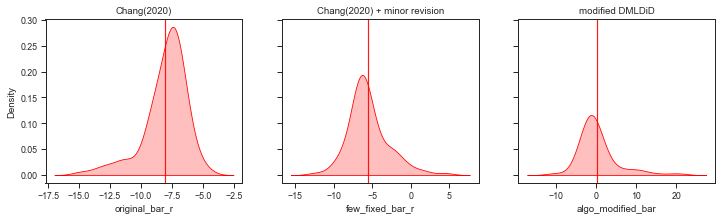

In [17]:
_label = [
    "Chang(2020)",
    "Chang(2020) + minor revision",
    "modified DMLDiD",
]
result_df = pd.DataFrame(
    {
        "original_bar_r": r_result,
        "few_fixed_bar_r": fixed_r_result,
        "algo_modified_bar": algo_modified_bar,
    }
)
fig, ax = plt.subplots(1, 3, sharex="col", sharey="row", figsize=(12, 3))
ax = ax.ravel()
for i, _col in enumerate(result_df.columns):
    sns.kdeplot(result_df[_col], shade=True, color="red", ax=ax[i])
    #ax[i].hist(result_df[_col], bins=100, alpha=0.5)
    ax[i].set_title(_label[i])
    # ax[i].axvline(x=0, alpha=0.5, color="black")
    ax[i].axvline(x=result_df[_col].mean(), alpha=0.9,color="red")
#fig.savefig("../fig/fixed_dataprocessing_result.png")
plt.show()

In [18]:
result_df.describe().T

,count,mean,std,min,25%,50%,75%,max
original_bar_r,100.0,-8.066211,1.770048,-14.871992,-8.908816,-7.618201,-6.979869,-4.651370
few_fixed_bar_r,100.0,-5.533137,2.654804,-12.425658,-6.933623,-6.049499,-4.253365,4.539452
algo_modified_bar,100.0,0.377283,5.038418,-11.049657,-2.320474,-0.880683,1.268184,21.427556


In [19]:
print("Done")

Done
